In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from wordcloud import WordCloud

In [2]:
df = pd.read_csv("../data/raw_analyst_ratings.csv")
df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [3]:
df.info()
df.describe(include='all')
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Unnamed: 0  1407328 non-null  int64 
 1   headline    1407328 non-null  object
 2   url         1407328 non-null  object
 3   publisher   1407328 non-null  object
 4   date        1407328 non-null  object
 5   stock       1407328 non-null  object
dtypes: int64(1), object(5)
memory usage: 64.4+ MB


Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

In [ ]:

# Create a new column containing headline character lengths
df['headline_length'] = df['headline'].astype(str).apply(len)

df['headline_length'].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

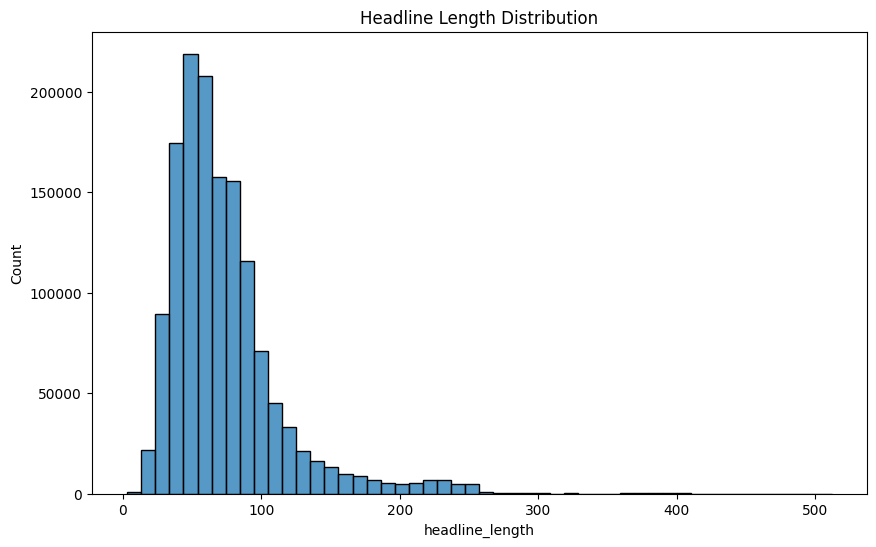

In [ ]:
# Plot distribution of headline lengths
plt.figure(figsize=(10,6))
sns.histplot(df['headline_length'], bins=50)
plt.title("Headline Length Distribution")
plt.show()

In [ ]:
# Explanation:
# The histogram visualizes the distribution of headline lengths.
# Most headlines cluster within a moderate range, indicating
# that publishers prefer short and clear financial news titles.
# Extremely long headlines appear less frequently.

In [ ]:
# Count the number of articles published by each publisher

publisher_counts = df['publisher'].value_counts().head(20)

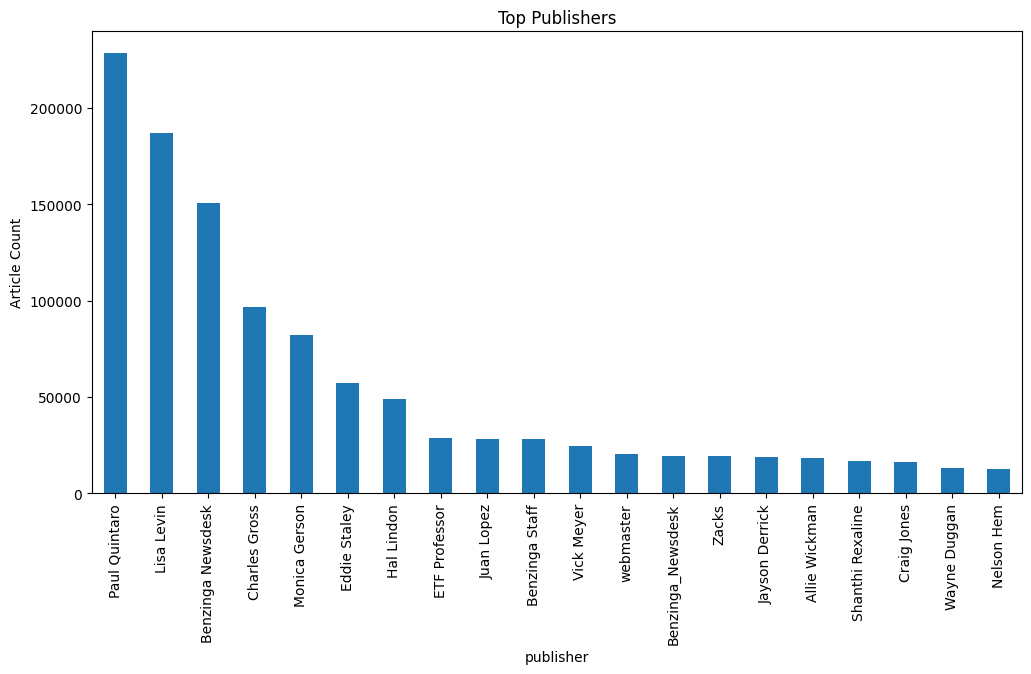

In [7]:
plt.figure(figsize=(12,6))
publisher_counts.plot(kind='bar')
plt.title("Top Publishers")
plt.ylabel("Article Count")
plt.show()

In [ ]:
# Explanation:
# This chart displays the most active news publishers in the dataset.
# A few publishers contribute a large number of articles,
# suggesting that major financial media organizations dominate news reporting.

In [ ]:
# ==============================
# Date Conversion and Time Series Analysis
# ==============================

# Convert the date column into datetime format
# format='mixed' handles inconsistent date formats
# errors='coerce' converts invalid dates into NaT

df['date'] = pd.to_datetime(df['date'], format='mixed', errors='coerce')
print(df['date'].dtype)

datetime64[ns, UTC-04:00]


In [12]:
daily_counts = df.groupby(df['date'].dt.date).size()

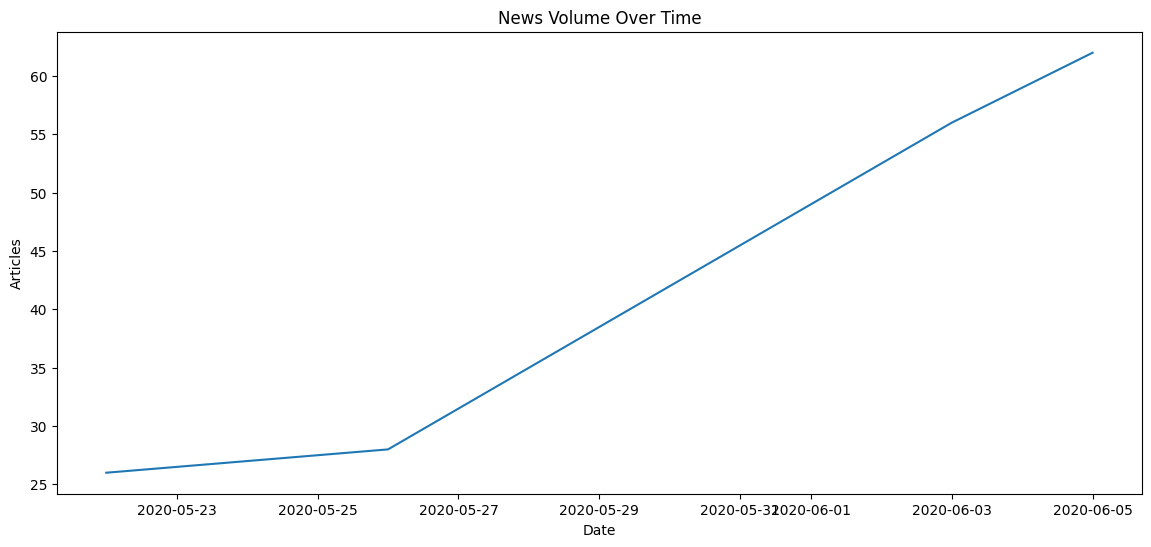

In [13]:
plt.figure(figsize=(14,6))
daily_counts.plot()
plt.title("News Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Articles")
plt.show()

In [ ]:

# ==============================
# Publishing Hour Analysis
# ==============================

# Extract publication hour from the datetime column

df['hour'] = df['date'].dt.hour

hourly_counts = df['hour'].value_counts().sort_index()

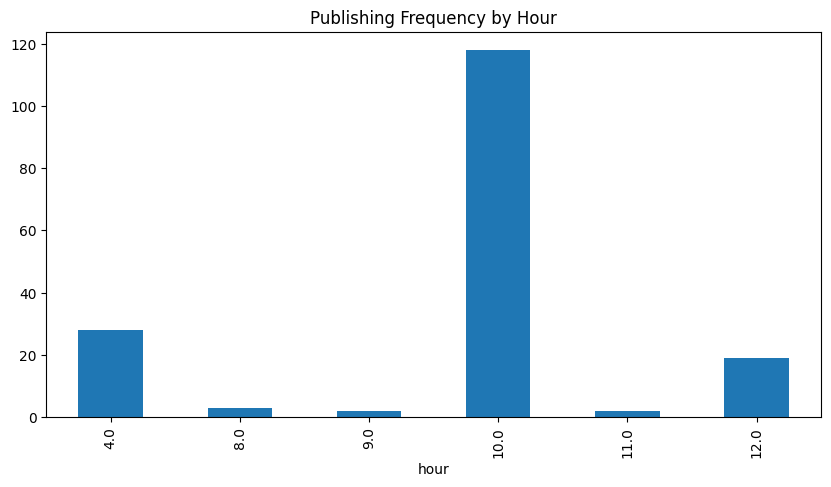

In [15]:
plt.figure(figsize=(10,5))
hourly_counts.plot(kind='bar')
plt.title("Publishing Frequency by Hour")
plt.show()

In [ ]:
# ==============================
# Keyword Extraction using TF-IDF
# ==============================

# Initialize TF-IDF vectorizer
# stop_words='english' removes common English words
# max_features=100 keeps top 100 important words

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=100
)

X = tfidf.fit_transform(df['headline'].astype(str))

keywords = tfidf.get_feature_names_out()

In [17]:
scores = X.sum(axis=0).A1

keyword_df = pd.DataFrame({
    'keyword': keywords,
    'score': scores
}).sort_values(by='score', ascending=False)

keyword_df.head(20)

,keyword,score
86,stocks,66645.882101
51,market,53205.042212
31,earnings,49570.513261
84,shares,49220.549697
73,reports,48889.307062
94,vs,48356.516515
17,benzinga,45512.090354
92,update,44195.247931
34,est,42654.917861
15,announces,40383.083544


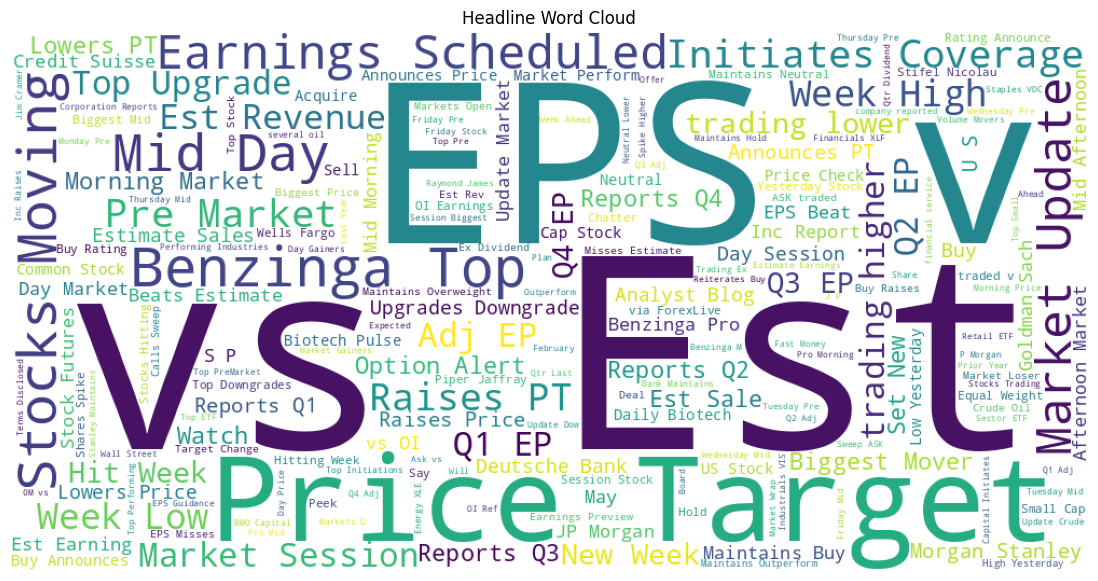

In [ ]:
# ==============================
# Word Cloud Visualization
# ==============================

# Combine all headlines into one text string

text = " ".join(df['headline'].astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Headline Word Cloud")
plt.show()

In [ ]:
# ==============================
# Topic Modeling using LDA
# ==============================

# Convert headlines into bag-of-words representation

vectorizer = CountVectorizer(
    stop_words='english',
    max_df=0.95,
    min_df=2
)

X_topics = vectorizer.fit_transform(df['headline'].astype(str))

lda = LatentDirichletAllocation(
    n_components=5,
    random_state=42
)

lda.fit(X_topics)

,n_components,5
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,10
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


In [21]:
words = vectorizer.get_feature_names_out()

for idx, topic in enumerate(lda.components_):
    print(f"\nTopic {idx+1}")
    print([words[i] for i in topic.argsort()[-10:]])


Topic 1
['10', '2019', '2018', 'etf', 'watch', 'etfs', 'scheduled', 'benzinga', 'stocks', 'earnings']

Topic 2
['52', 'lower', 'stock', 'week', 'higher', 'companies', 'says', 'stocks', 'trading', 'shares']

Topic 3
['target', 'maintains', 'raises', 'buy', 'pt', 'sales', 'reports', 'eps', 'est', 'vs']

Topic 4
['low', 'highest', 'set', 'industry', 'reports', '52', 'week', 'announces', 'stocks', 'new']

Topic 5
['downgrades', 'biggest', 'benzinga', 'day', 'moving', 'session', 'update', 'stocks', 'mid', 'market']


In [23]:
# ==============================
# Publisher Domain Analysis
# ==============================


df['domain'] = df['publisher'].str.extract(r'@([\w\.-]+)')
domain_counts = df['domain'].value_counts().head(10)

# Display top domains
print(domain_counts)

domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64
